# 01 — Taylor polynomials

A Taylor polynomial of degree $n$ at $a$ is
$$
T_n(x) = \sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!}(x-a)^k.
$$
The Lagrange remainder is bounded by
$$
|R_n(x)| \le \frac{M}{(n+1)!}|x-a|^{n+1},
\quad M \ge \sup_{\xi}|f^{(n+1)}(\xi)|.
$$

We use `numethods.taylor_polynomial` and `numethods.taylor_remainder_bound`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

import sympy as sp
from numethods import taylor_polynomial, taylor_remainder_bound


## Approximating $\sin(x)$ around $0$

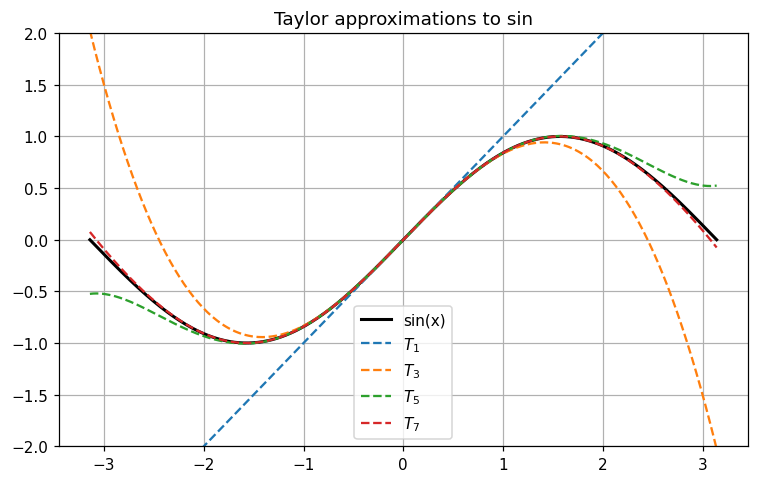

In [2]:
z = sp.Symbol('z')
xs = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots()
ax.plot(xs, np.sin(xs), 'k', lw=2, label='sin(x)')
for n in [1, 3, 5, 7]:
    p = taylor_polynomial(sp.sin(z), 0.0, n)
    ax.plot(xs, p(xs), '--', label=f'$T_{n}$')
ax.set_ylim(-2, 2); ax.legend(); ax.set_title('Taylor approximations to sin')
fig.tight_layout(); plt.show()


## Error bound vs actual error for $e^x$ around $0$

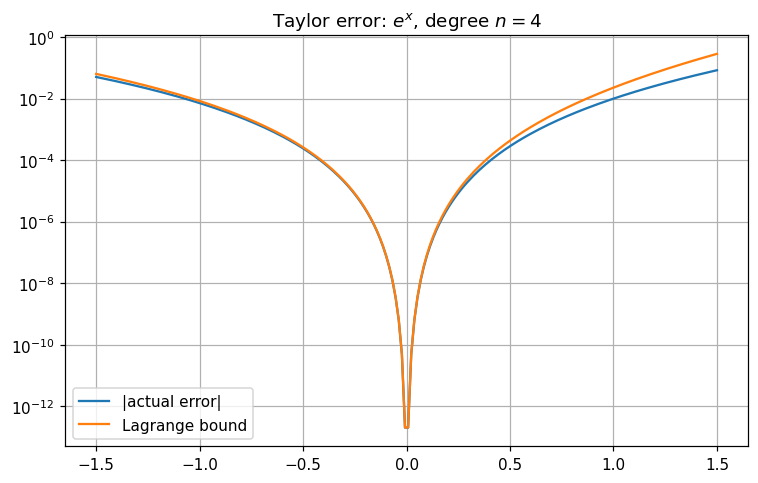

In [3]:
xs = np.linspace(-1.5, 1.5, 200)
n = 4
p = taylor_polynomial(sp.exp(z), 0.0, n)
actual = np.abs(np.exp(xs) - p(xs))
bound = np.array([taylor_remainder_bound(sp.exp(z), 0.0, n, x) for x in xs])

fig, ax = plt.subplots()
ax.semilogy(xs, actual, label='|actual error|')
ax.semilogy(xs, bound,  label='Lagrange bound')
ax.legend(); ax.set_title(f'Taylor error: $e^x$, degree $n={n}$')
fig.tight_layout(); plt.show()


This notebook demonstrates `numethods.taylor`. The Lagrange bound is conservative but always valid; notice it sits above the actual error everywhere.